<a href="https://colab.research.google.com/github/carolvieirav/Churn_A3Data/blob/main/01_EDA_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Churn — Análise Exploratória

**Contexto:** Uma empresa de telecom pede ajuda para entender seu churn de 26,5%. O produto tem **custo elevado de instalação**. Cada cliente perdido representa setup não amortizado + receita futura perdida + custo de reposição.

**Abordagem:** Cada análise aqui responde uma pergunta de negócio específica. Os modelos exploratórios que seguem neste notebook servem para *entender* o problema, não para classificar clientes em produção.

**Perguntas que este notebook responde:**
1. Qual é a escala real do problema em R$?
2. Quando estamos perdendo clientes?
3. Quem está saindo? existe um perfil?
4. Por que estão saindo?
5. O que podemos fazer que realmente vai mover o ponteiro?

## Install & Imports

In [80]:
!pip install -U ydata-profiling
!pip install -q shap xgboost

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder

import warnings; warnings.filterwarnings('ignore')

## Descritivo

In [64]:
import pandas as pd
from ydata_profiling import ProfileReport

df = pd.read_excel('Customer-Churn.xlsx')
profile = ProfileReport(df, title="Relatório de Análise Exploratória", explorative=True)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 17.53it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

---
## Pergunta 1: Qual é a escala real do problema?
*Dimensão do problema em R$.*

In [66]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['y'] = (df['Churn'] == 'Yes').astype(int)

# Segmentação da Base
df_churn = df[df['y'] == 1]
df_retidos = df[df['y'] == 0]

# Cálculo de Métricas Gerais
total = len(df)
churners = len(df_churn)
retidos = len(df_retidos)
churn_rate = churners / total

# Cálculo de Métricas Financeiras e de Negócio
# Receita e ARPU
rec_mensal = df_churn['MonthlyCharges'].sum()
rec_anual = rec_mensal * 12
arpu_churn = df_churn['MonthlyCharges'].mean()
arpu_retido = df_retidos['MonthlyCharges'].mean()
gap_arpu = (arpu_churn / arpu_retido) - 1

# LTV e Tempo de Vida (Tenure)
tc_churn = df_churn['TotalCharges'].mean()
tc_retido = df_retidos['TotalCharges'].mean()
tenure_impl_churn = tc_churn / arpu_churn
tenure_impl_retido = tc_retido / arpu_retido

# Projeções de Impacto
alavanca_1pp = total * 0.01 * arpu_churn
potencial_n_realizado = (tenure_impl_retido * arpu_churn - tc_churn) * churners

print("VISÃO GERAL DA BASE")
print(f"   Total de clientes:      {total:,}")
print(f"   Clientes Retidos:       {retidos:,} ({retidos/total:.1%})")
print(f"   Clientes Perdidos:      {churners:,} ({churn_rate:.1%})")
print(f"   Proporção de Perda:     1 a cada {1/churn_rate:.0f} clientes")

print("\nANÁLISE DE ARPU (Receita Mensal)")
print(f"   ARPU Churners:          R$ {arpu_churn:.2f} /mês")
print(f"   ARPU Retidos:           R$ {arpu_retido:.2f} /mês")
print(f"   Gap de Valor:           Churners pagavam {gap_arpu:.1%} a mais")

print("\nCICLO DE VIDA (TotalCharges & Tenure Implícito)")
print(f"   LTV Churners:           R$ {tc_churn:,.2f}  (~{tenure_impl_churn:.1f} meses)")
print(f"   LTV Retidos:            R$ {tc_retido:,.2f}  (~{tenure_impl_retido:.1f} meses)")

print("\nIMPACTO FINANCEIRO GLOBAL")
print(f"   Receita em Risco:       R$ {rec_mensal:,.0f} /mês | R$ {rec_anual:,.0f} /ano")
print(f"   Alavanca (Redução 1pp): Preserva R$ {alavanca_1pp:,.0f} /mês")
print(f"   Potencial Desperdiçado: R$ {potencial_n_realizado:,.0f} (Devido à saída precoce)")

VISÃO GERAL DA BASE
   Total de clientes:      7,043
   Clientes Retidos:       5,174 (73.5%)
   Clientes Perdidos:      1,869 (26.5%)
   Proporção de Perda:     1 a cada 4 clientes

ANÁLISE DE ARPU (Receita Mensal)
   ARPU Churners:          R$ 74.44 /mês
   ARPU Retidos:           R$ 61.27 /mês
   Gap de Valor:           Churners pagavam 21.5% a mais

CICLO DE VIDA (TotalCharges & Tenure Implícito)
   LTV Churners:           R$ 1,531.80  (~20.6 meses)
   LTV Retidos:            R$ 2,549.91  (~41.6 meses)

IMPACTO FINANCEIRO GLOBAL
   Receita em Risco:       R$ 139,131 /mês | R$ 1,669,570 /ano
   Alavanca (Redução 1pp): Preserva R$ 5,243 /mês
   Potencial Desperdiçado: R$ 2,927,829 (Devido à saída precoce)


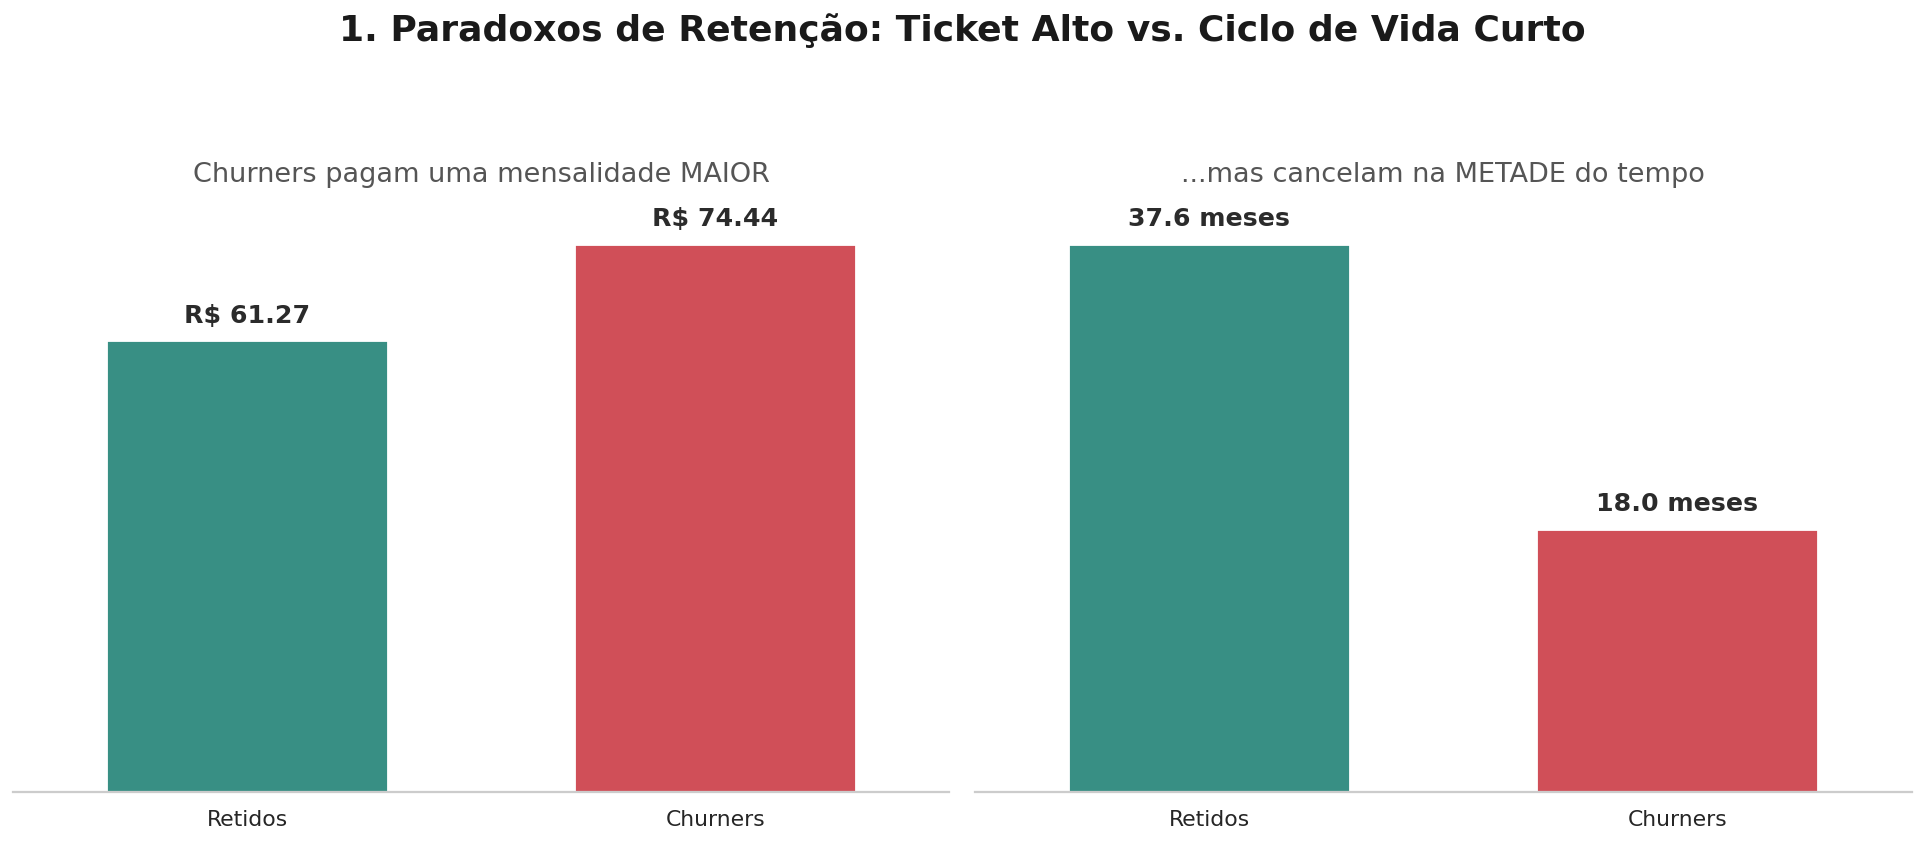

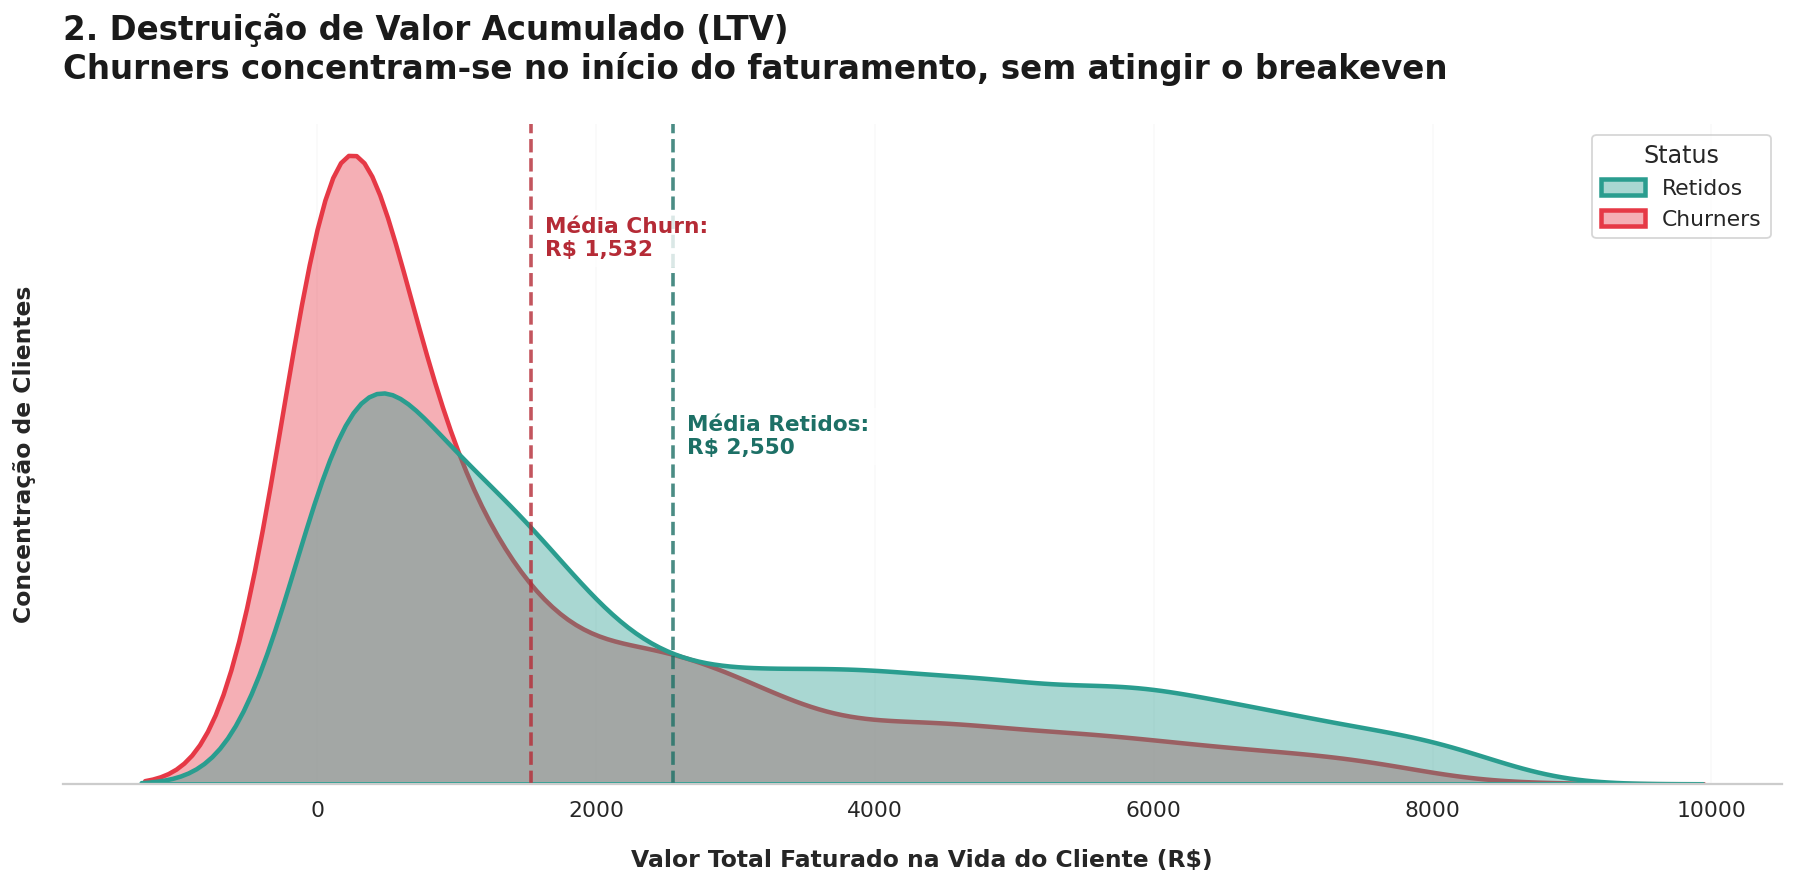

In [72]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['text.color'] = '#2b2b2b'
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['xtick.color'] = '#555555'

sns.set_theme(style="white", font_scale=1.1)

cores = {'Retidos': '#2A9D8F', 'Churners': '#E63946'}
df['Status'] = df['y'].map({0: 'Retidos', 1: 'Churners'})

# O Paradoxo do Valor (ARPU vs. Tenure)
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 6))
fig1.suptitle('1. Paradoxos de Retenção: Ticket Alto vs. Ciclo de Vida Curto',
             fontsize=20, fontweight='bold', color='#1a1a1a', y=1.08)

# Mensalidade Média (ARPU)
sns.barplot(data=df, x='Status', y='MonthlyCharges', palette=cores, ax=axes1[0], errorbar=None, width=0.6)
axes1[0].set_title('Churners pagam uma mensalidade MAIOR', fontsize=15, color='#555555', pad=20)
axes1[0].set_ylabel('')
axes1[0].set_xlabel('')

for p in axes1[0].patches:
    axes1[0].annotate(f'R$ {p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontweight='bold', fontsize=14, color='#2b2b2b', xytext=(0, 8), textcoords='offset points')

# Tempo de Casa Médio (Tenure)
sns.barplot(data=df, x='Status', y='tenure', palette=cores, ax=axes1[1], errorbar=None, width=0.6)
axes1[1].set_title('...mas cancelam na METADE do tempo', fontsize=15, color='#555555', pad=20)
axes1[1].set_ylabel('')
axes1[1].set_xlabel('')

for p in axes1[1].patches:
    axes1[1].annotate(f'{p.get_height():.1f} meses', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontweight='bold', fontsize=14, color='#2b2b2b', xytext=(0, 8), textcoords='offset points')

# Refinamento de eixos
for ax in axes1:
    sns.despine(ax=ax, left=True)
    ax.yaxis.set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

print("\n")

# Impacto no Valor Acumulado (LTV)
fig2, ax2 = plt.subplots(figsize=(14, 7))

sns.kdeplot(data=df, x='TotalCharges', hue='Status', fill=True, palette=cores,
            alpha=0.4, linewidth=2.5, ax=ax2, common_norm=False)

ax2.set_title('2. Destruição de Valor Acumulado (LTV)\nChurners concentram-se no início do faturamento, sem atingir o breakeven',
              fontsize=18, fontweight='bold', color='#1a1a1a', pad=25, loc='left')

ax2.set_xlabel('Valor Total Faturado na Vida do Cliente (R$)', fontsize=13, fontweight='bold', labelpad=15)
ax2.set_ylabel('Concentração de Clientes', fontsize=13, fontweight='bold', labelpad=15)

# Médias Reais
mean_ret = df[df['y']==0]['TotalCharges'].mean()
mean_churn = df[df['y']==1]['TotalCharges'].mean()

# Linhas de referência verticais
ax2.axvline(mean_churn, color='#B52B36', linestyle='--', linewidth=2, alpha=0.8)
ax2.text(mean_churn + 100, ax2.get_ylim()[1]*0.8, f'Média Churn:\nR$ {mean_churn:,.0f}',
         color='#B52B36', fontweight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax2.axvline(mean_ret, color='#1D7066', linestyle='--', linewidth=2, alpha=0.8)
ax2.text(mean_ret + 100, ax2.get_ylim()[1]*0.5, f'Média Retidos:\nR$ {mean_ret:,.0f}',
         color='#1D7066', fontweight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

sns.despine(left=True)
ax2.set_yticks([])
ax2.spines['bottom'].set_color('#cccccc')
ax2.grid(axis='x', color='#f0f0f0', linestyle='-', linewidth=1, zorder=0)

plt.tight_layout()
plt.show()

**1. Impacto no ARPU e Receita Recorrente (MRR)**

* **Concentração no Alto Valor:** A empresa atrai contas rentáveis, mas falha em retê-las. Os clientes que cancelam (26,5% da base) possuem um ticket médio de **R\$ 74,44/mês**, um valor **21,5% maior** que a média da base retida (R\$ 61,27).

* **Déficit Anual:** A evasão contínua desse perfil premium gera uma perda de **R\$ 1,67 milhão ao ano** em receita recorrente que deixa de entrar no caixa.

* **Alavanca de Retenção:** Melhorias marginais têm alto impacto financeiro. Reduzir a taxa de churn em apenas 1 p.p. preserva **R\$ 5.243 mensais** de forma imediata.

**2. Impacto no LTV e Custo de Oportunidade**

* **Saída Precoce:** Os churners abandonam o serviço literalmente na metade do ciclo de vida típico. Eles permanecem ativos por cerca de **20,6 meses** (acumulando R\$ 1.531), enquanto os clientes retidos chegam a **41,6 meses** (R\$ 2.549).

* **O Tamanho do Gap:** Considerando o ticket mais alto (R\$ 74,44), se o cliente perdido permanecesse os mesmos 41,6 meses da base saudável, ele deixaria **R\$ 3.097** na empresa.

* **Custo de Oportunidade da Saída Prematura:** A interrupção prematura do contrato representa um custo de oportunidade de ~R\$ 1.566 por usuário perdido. Projetando para os 1.869 churners, há **R\$ 2,92 milhões** não realizados nesta coorte.

**▶ Conclusão**

A operação de aquisição é eficiente ao trazer clientes com capacidade de pagamento acima da média. O gargalo do negócio não é o topo de funil, mas sim a incapacidade de entregar valor contínuo para as contas premium, fazendo com que o segmento mais lucrativo da base saia antes de atingir sua maturidade financeira.

---
## Pergunta 2: Quando estamos perdendo clientes?
*O timing do churn define onde intervir.*

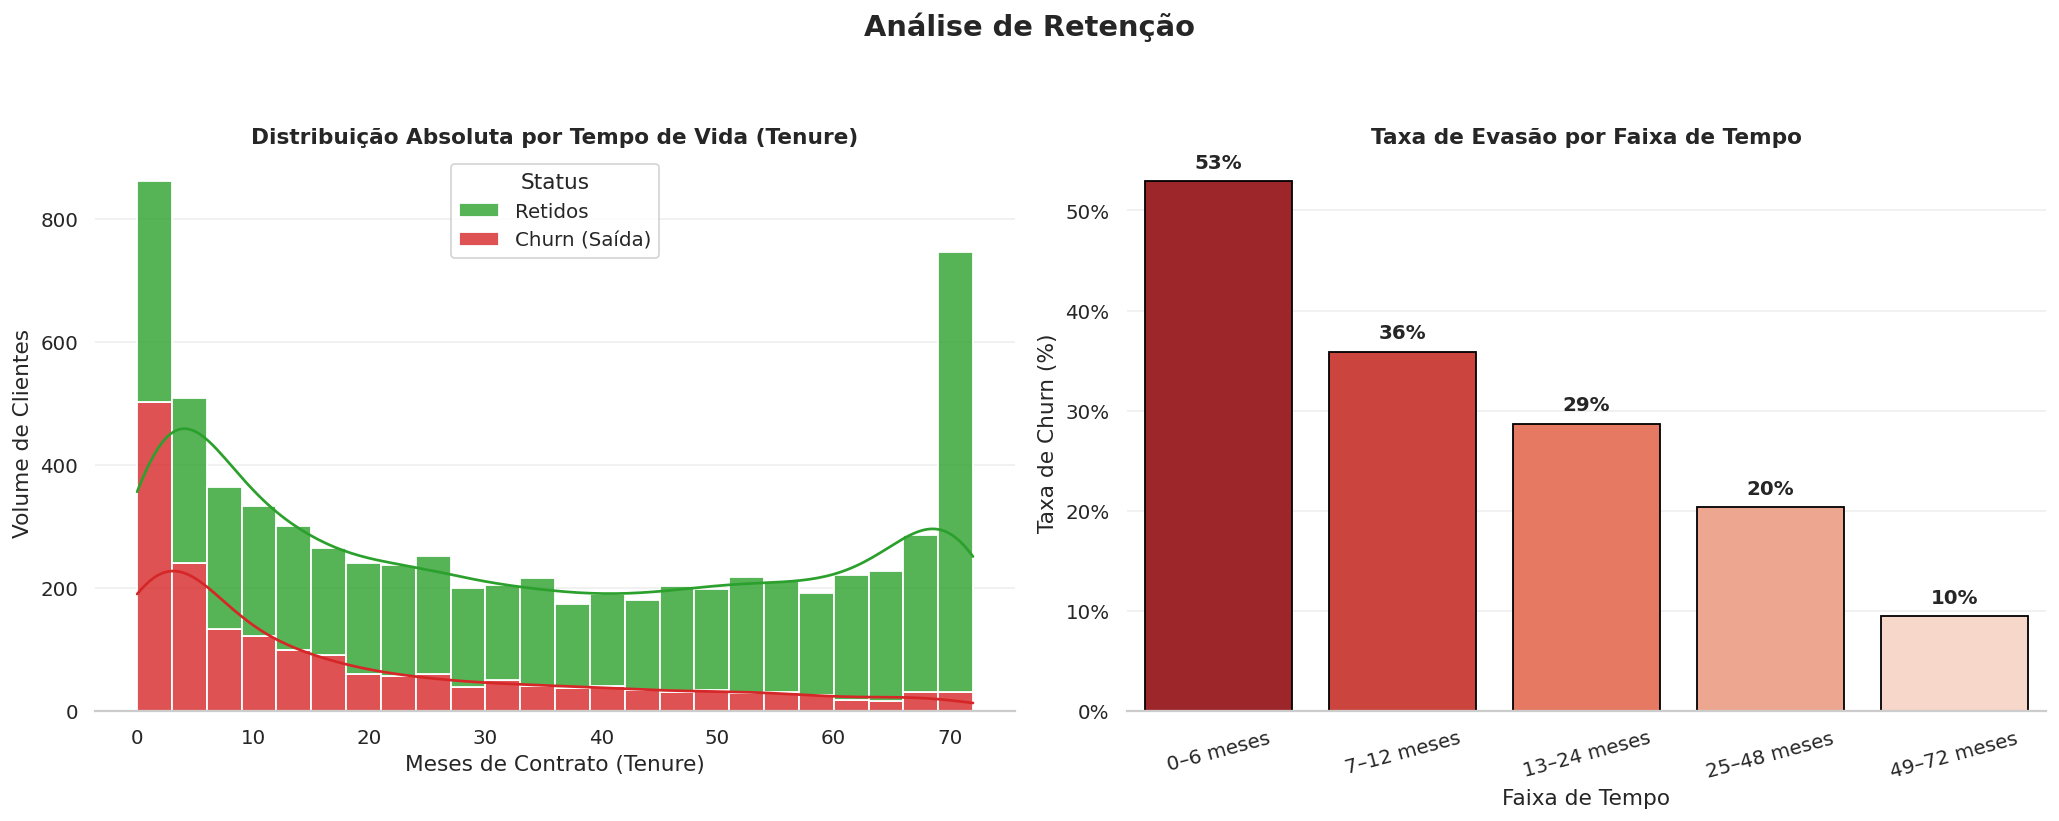

In [41]:
sns.set_theme(style="whitegrid")
cores_status = {0: '#2ca02c', 1: '#d62728'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise de Retenção', fontsize=16, fontweight='bold', y=1.05)

# A Curva Exata de Cancelamento
sns.histplot(data=df, x='tenure', hue='y', multiple="stack",
             bins=24, kde=True, palette=cores_status, ax=axes[0], alpha=0.8)

axes[0].set_title('Distribuição Absoluta por Tempo de Vida (Tenure)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Meses de Contrato (Tenure)')
axes[0].set_ylabel('Volume de Clientes')

legend = axes[0].get_legend()
if legend:
    legend.set_title('Status')
    for t, l in zip(legend.texts, ['Retidos', 'Churn (Saída)']): t.set_text(l)

# Taxa de Churn por Faixa
sns.barplot(data=tenure_stats, x='tenure_faixa', y='churn_rate',
            palette='Reds_r', ax=axes[1], edgecolor='black')

axes[1].set_title('Taxa de Evasão por Faixa de Tempo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Faixa de Tempo')
axes[1].set_ylabel('Taxa de Churn (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=15)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold',
                     xytext=(0, 5), textcoords='offset points')

sns.despine(left=True)
plt.tight_layout()
plt.show()

---
## Pergunta 3: Quem está saindo? Existe um perfil claro?
*Identificar os segmentos de maior risco é o que permite priorizar ações.*

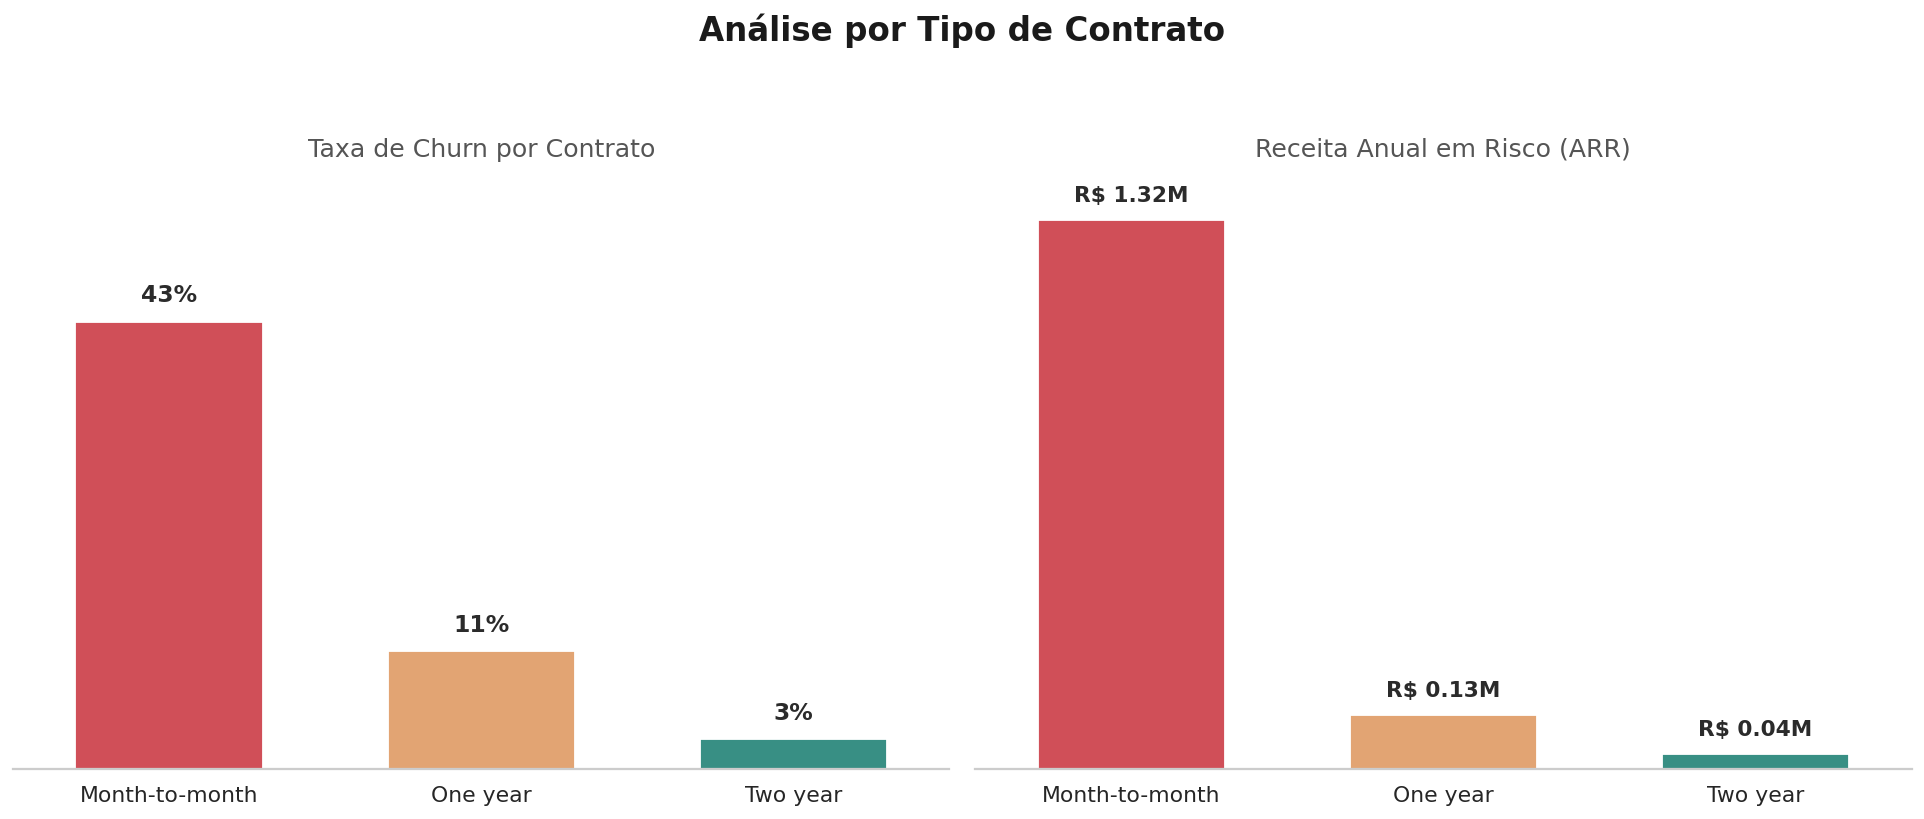

In [49]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['text.color'] = '#2b2b2b'
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['xtick.color'] = '#555555'

sns.set_theme(style="white", font_scale=1.1)

contrato_stats = df.groupby('Contract').agg(
    clientes=('y','count'),
    churners=('y','sum'),
    churn_rate=('y','mean'),
    arpu=('MonthlyCharges','mean'),
    tenure_med=('tenure','median')
).reset_index()

contrato_stats['receita_risco_anual'] = contrato_stats['churners'] * contrato_stats['arpu'] * 12

cores_contrato = {
    'Month-to-month': '#E63946',
    'One year': '#F4A261',
    'Two year': '#2A9D8F'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Análise por Tipo de Contrato', fontsize=18, fontweight='bold', color='#1a1a1a', y=1.05)

sns.barplot(data=contrato_stats, x='Contract', y=contrato_stats['churn_rate']*100,
            palette=cores_contrato, ax=axes[0], width=0.6)
axes[0].set_title('Taxa de Churn por Contrato', fontsize=14, color='#555555', pad=20)
axes[0].set_ylabel('')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 55)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontweight='bold', fontsize=13, color='#2b2b2b', xytext=(0, 8), textcoords='offset points')

sns.barplot(data=contrato_stats, x='Contract', y=contrato_stats['receita_risco_anual']/1e6,
            palette=cores_contrato, ax=axes[1], width=0.6)
axes[1].set_title('Receita Anual em Risco (ARR)', fontsize=14, color='#555555', pad=20)
axes[1].set_ylabel('')
axes[1].set_xlabel('')

for p in axes[1].patches:
    axes[1].annotate(f'R$ {p.get_height():.2f}M', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontweight='bold', fontsize=12, color='#2b2b2b', xytext=(0, 8), textcoords='offset points')

sns.despine(left=True, bottom=False)
axes[0].yaxis.set_visible(False)
axes[1].yaxis.set_visible(False)
axes[0].spines['bottom'].set_color('#cccccc')
axes[1].spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

m2m = contrato_stats[contrato_stats['Contract']=='Month-to-month'].iloc[0]

**Impacto Direto na Base:**

Taxa de Churn: 43%. Um risco 15x superior aos contratos de 2 anos.

Concentração de Perda: 1,655 de um total de 1,869 churners pertencem a esta modalidade.

Receita em Risco: R\$ 1.32M em receita recorrente anual (ARR) sob ameaça direta.

**Conclusão:**

O modelo de contrato Month-to-month apresenta uma falha estrutural de negócio: a ausência de mecanismos de fidelização torna o produto incompatível com a necessidade de amortização do custo de instalação, custo operacional que existe na entrada do cliente e precisa ser diluído ao longo do tempo de contrato. O efeito aparece no TotalCharges:
churners acumularam R\$1.532 contra R\$2.550 dos retidos.

*O CAC não está disponível nos dados e não foi utilizado neste cálculo.*

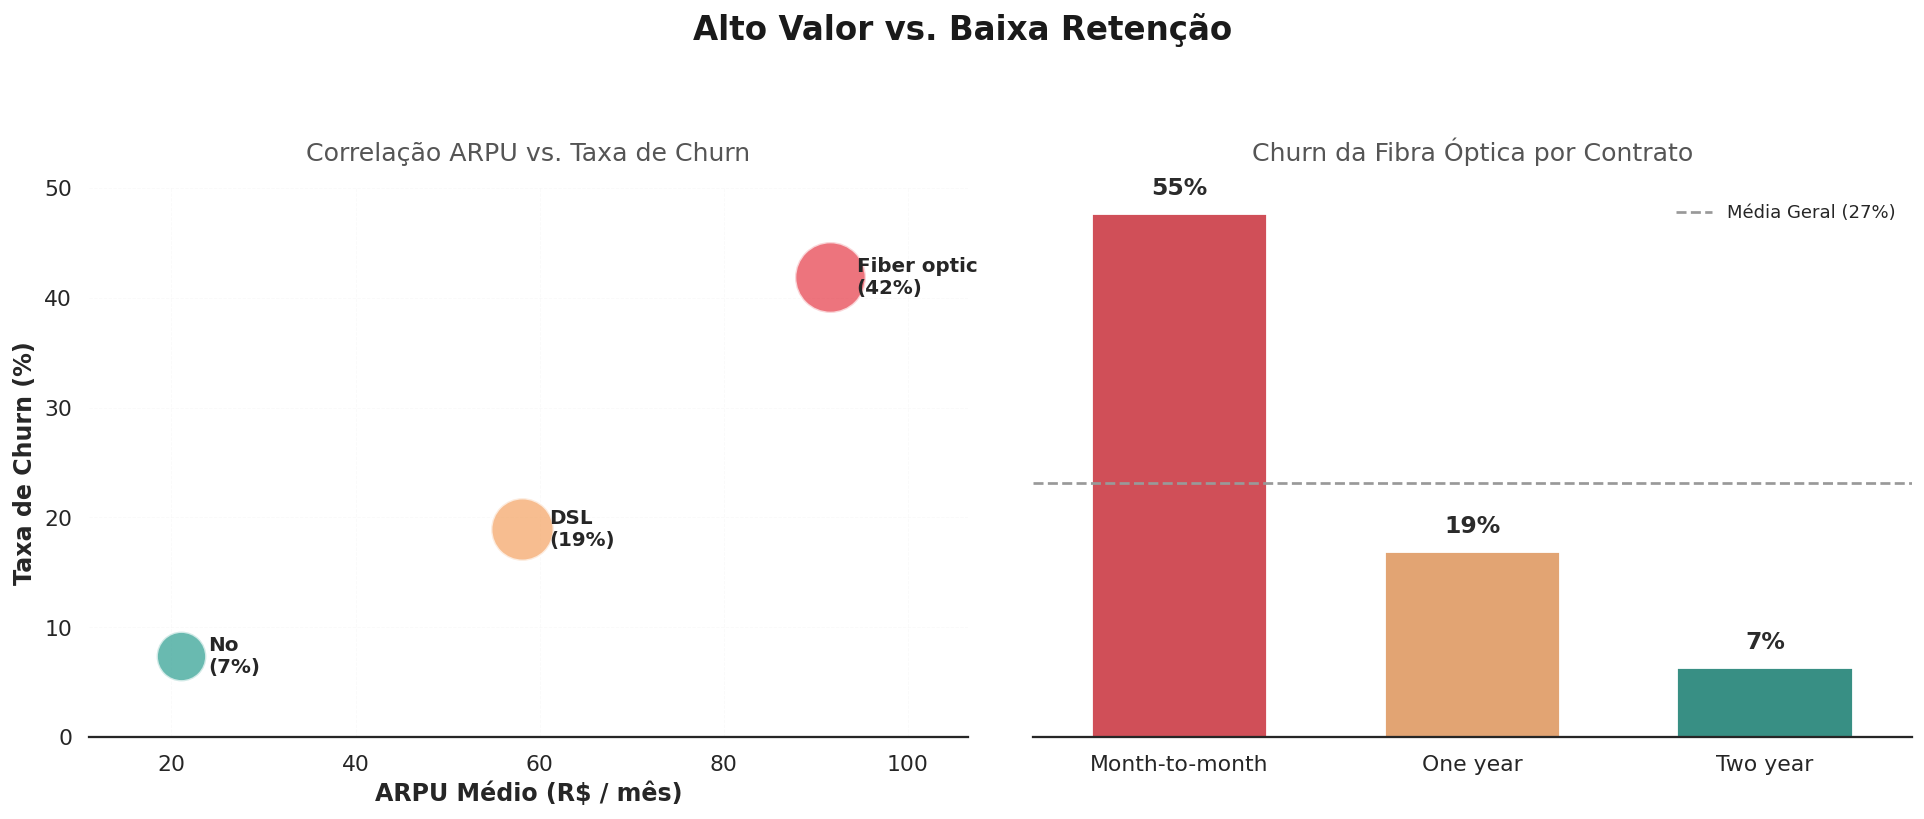

In [53]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['text.color'] = '#2b2b2b'
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['xtick.color'] = '#555555'

sns.set_theme(style="white", font_scale=1.1)

internet_stats = df.groupby('InternetService').agg(
    clientes=('y','count'),
    churn_rate=('y', 'mean'),
    arpu=('MonthlyCharges', 'mean')
).reset_index()

cores_internet = {'Fiber optic': '#E63946', 'DSL': '#F4A261', 'No': '#2A9D8F'}
cores_contrato = {'Month-to-month': '#E63946', 'One year': '#F4A261', 'Two year': '#2A9D8F'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Alto Valor vs. Baixa Retenção', fontsize=18, fontweight='bold', color='#1a1a1a', y=1.05)

for i, row in internet_stats.iterrows():
    axes[0].scatter(row['arpu'], row['churn_rate']*100,
                    s=row['clientes']/2,
                    color=cores_internet[row['InternetService']],
                    alpha=0.7, edgecolors='white', linewidth=1.5)

    axes[0].annotate(f"{row['InternetService']}\n({row['churn_rate']:.0%})",
                     (row['arpu'], row['churn_rate']*100),
                     xytext=(15, 0), textcoords='offset points',
                     fontsize=11, fontweight='bold', va='center')

axes[0].set_title('Correlação ARPU vs. Taxa de Churn', fontsize=14, color='#555555', pad=15)
axes[0].set_xlabel('ARPU Médio (R$ / mês)', fontweight='bold')
axes[0].set_ylabel('Taxa de Churn (%)', fontweight='bold')
axes[0].set_xlim(internet_stats['arpu'].min()-10, internet_stats['arpu'].max()+15)
axes[0].set_ylim(0, 50)
axes[0].grid(color='#eeeeee', linestyle='--', linewidth=0.5)

fiber_contrato = df[df['InternetService']=='Fiber optic'].groupby('Contract')['y'].mean()*100
fiber_contrato = fiber_contrato.reindex(['Month-to-month', 'One year', 'Two year'])

sns.barplot(x=fiber_contrato.index, y=fiber_contrato.values, palette=cores_contrato, ax=axes[1], width=0.6)
axes[1].set_title('Churn da Fibra Óptica por Contrato', fontsize=14, color='#555555', pad=15)
axes[1].axhline(df['y'].mean()*100, ls='--', color='#999999', lw=1.5, label=f'Média Geral ({df["y"].mean():.0%})')
axes[1].set_ylabel('')
axes[1].set_xlabel('')

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontweight='bold', fontsize=13, color='#2b2b2b', xytext=(0, 8), textcoords='offset points')

sns.despine(left=True)
axes[1].yaxis.set_visible(False)
axes[1].legend(frameon=False, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

fiber_ch = df[df['InternetService']=='Fiber optic']['y'].mean()
dsl_ch = df[df['InternetService']=='DSL']['y'].mean()

**Segmento Premium:**

Falha na Entrega de Valor: O serviço de Fiber Optic apresenta uma taxa de churn de 42%, quase o dobro do registrado pelo serviço DSL (19%).

Clientes Fiber (ARPU R\$92) churnam mais que clientes DSL (ARPU R\$58).
Os dados mostram correlação entre ARPU alto e churn alto. A causa —
se é o preço, a qualidade ou a expectativa criada na venda — não pode
ser determinada com os dados disponíveis.

**Risco Estrutural:**

Mesmo em contratos de longo prazo, a taxa de churn da Fibra Óptica permanece elevada. No modelo Month-to-month, a evasão é crítica, indicando que a promessa do produto não sobrevive aos primeiros ciclos de faturamento e uso.

Hipótese a investigar (requer dados externos): o churn elevado
no Fiber pode indicar descompasso entre expectativa de venda e
entrega técnica

In [67]:
df['tem_internet'] = (df['InternetService'] != 'No').astype(int)
df['n_services'] = (df[['OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies']]=='Yes').sum(axis=1)

print(df.groupby(['tem_internet','n_services'])['y'].agg(['mean','count']).round(3))

                          mean  count
tem_internet n_services              
0            0           0.074   1526
1            0           0.522    693
             1           0.458    966
             2           0.358   1033
             3           0.274   1118
             4           0.223    852
             5           0.124    571
             6           0.053    284


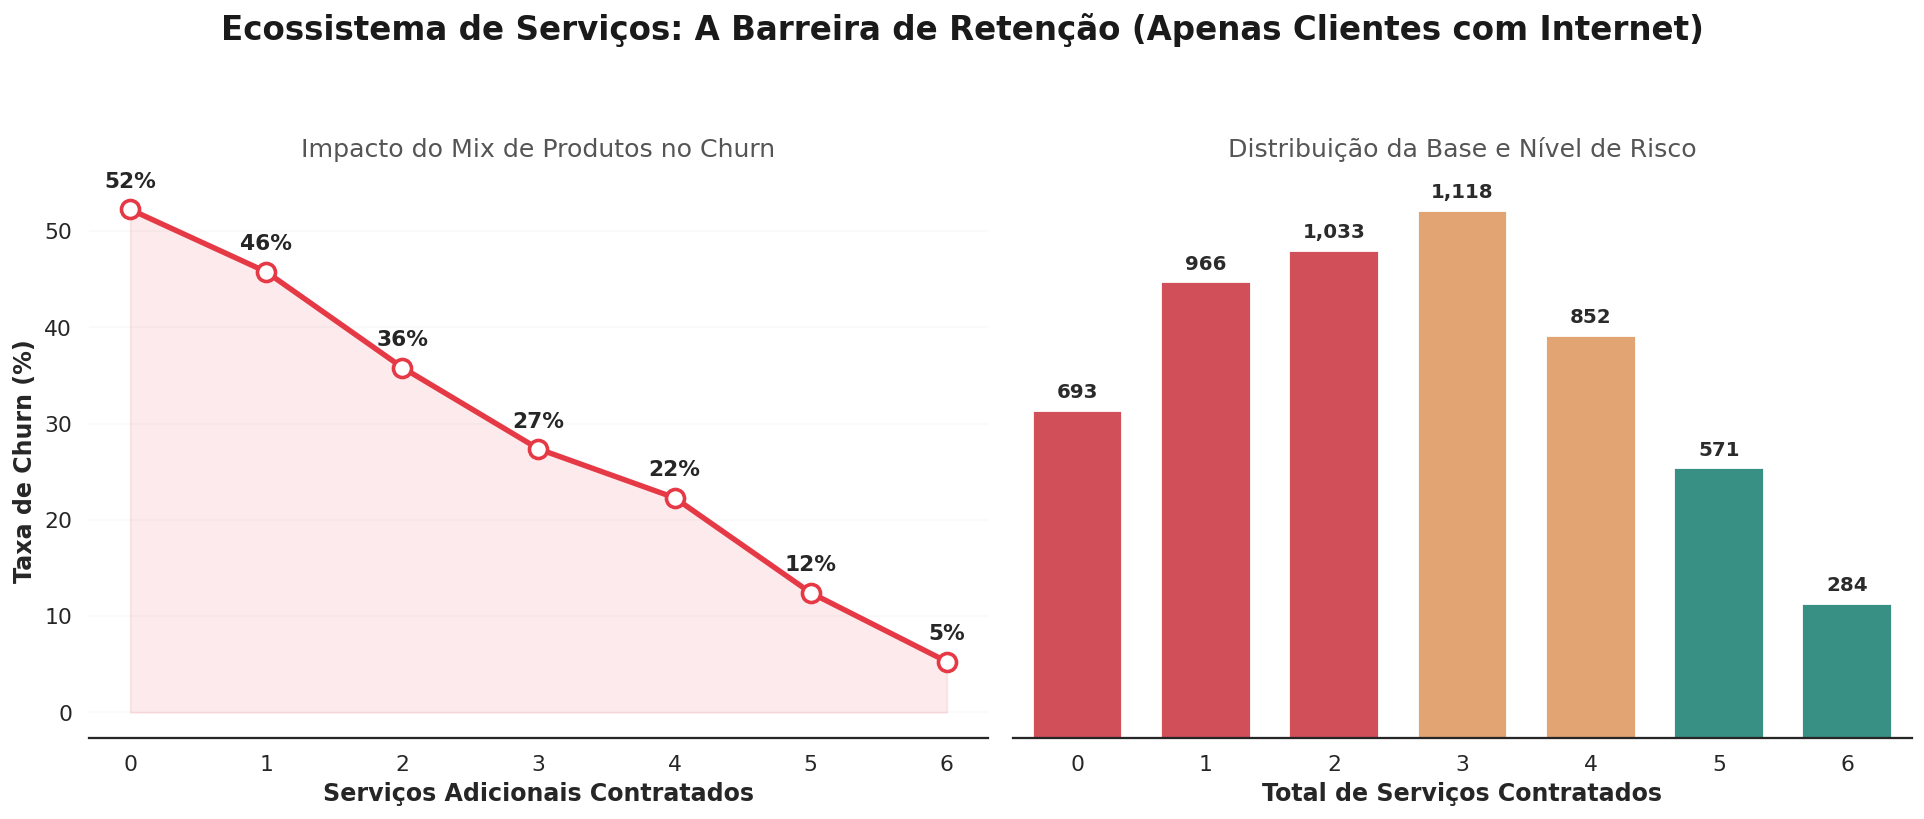

In [70]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['text.color'] = '#2b2b2b'
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['xtick.color'] = '#555555'

sns.set_theme(style="white", font_scale=1.1)

df_internet = df[df['InternetService'] != 'No'].copy()
svc = df_internet.groupby('n_services')['y'].agg(churn_rate='mean', clientes='count').reset_index()

def get_risk_color(rate):
    if rate > 0.35: return '#E63946' # Alto Risco
    if rate > 0.20: return '#F4A261' # Médio Risco
    return '#2A9D8F'                # Baixo Risco

svc['color'] = svc['churn_rate'].apply(get_risk_color)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Ecossistema de Serviços: A Barreira de Retenção (Apenas Clientes com Internet)',
             fontsize=18, fontweight='bold', color='#1a1a1a', y=1.05)

# 1. Curva de Retenção
axes[0].plot(svc['n_services'], svc['churn_rate'] * 100, color='#E63946', lw=3,
             marker='o', markersize=10, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(svc['n_services'], svc['churn_rate'] * 100, color='#E63946', alpha=0.1)
axes[0].set_title('Impacto do Mix de Produtos no Churn', fontsize=14, color='#555555', pad=15)
axes[0].set_xlabel('Serviços Adicionais Contratados', fontweight='bold')
axes[0].set_ylabel('Taxa de Churn (%)', fontweight='bold')
axes[0].set_xticks(svc['n_services'])

for i, row in svc.iterrows():
    axes[0].annotate(f"{row['churn_rate']:.0%}", (row['n_services'], row['churn_rate']*100),
                     textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold', fontsize=12)

# 2. Distribuição de Volume
sns.barplot(data=svc, x='n_services', y='clientes', palette=svc['color'].tolist(), ax=axes[1], width=0.7)
axes[1].set_title('Distribuição da Base e Nível de Risco', fontsize=14, color='#555555', pad=15)
axes[1].set_xlabel('Total de Serviços Contratados', fontweight='bold')
axes[1].set_ylabel('')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontweight='bold', fontsize=11, color='#2b2b2b', xytext=(0, 5), textcoords='offset points')

sns.despine(left=True)
axes[1].yaxis.set_visible(False)
axes[0].grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

## Serviços Adicionais: O Switching Cost que Retém Clientes

Isolando os 5.517 clientes com internet, a relação é direta:
quanto mais serviços contratados, menor o churn, sem exceção.

| Serviços adicionais | Churn |
|---|---|
| 0 | 52% |
| 1 | 46% |
| 2 | 36% |
| 3 | 27% |
| 4 | 22% |
| 5 | 12% |
| 6 | 5% |

**Por que isso acontece?** Cada serviço adicional (Security, Backup,
Tech Support) cria uma dependência funcional. Cancelar a conta significa
perder todos esses serviços de uma vez. Quanto mais serviços, maior o
custo percebido de sair. Isso é switching cost: não é o cliente gostar
mais da empresa, é cancelar ter ficado caro demais.

**O grupo mais urgente:** 693 clientes têm internet e nenhum serviço
adicional. Churn de 52%. Para eles, cancelar não custa nada em termos
de perda funcional, saem sem deixar nada para trás.

**O salto mais rentável:** migrar um cliente de 1 para 2 serviços reduz
o churn em 10pp (46% → 36%). É o maior ganho marginal de toda a curva —
o segundo serviço vale mais que qualquer outro em termos de retenção.

**Conclusão:**

Tech Support e Online Security não são produtos de upsell.
São o mecanismo que faz o cliente ficar. Oferecer um deles a um cliente
de alto risco não é uma forma de retenção.

1.659 clientes estão em 0-1 serviços com churn médio de 48,5%.
Este é o grupo com maior potencial de impacto por uma única ação de
cross-sell.

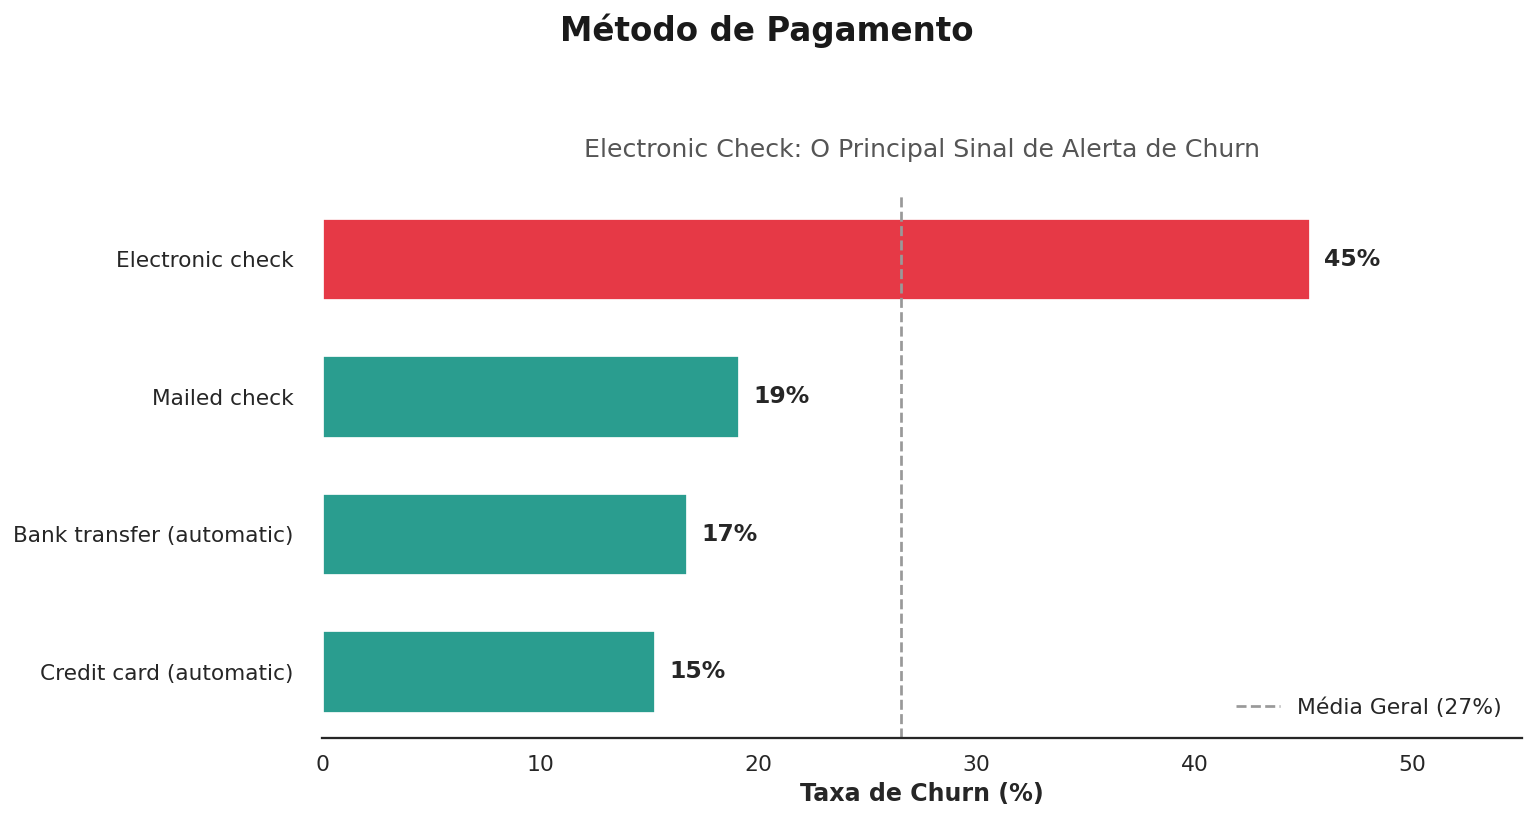

0.4528541226215645 0.1598173515981735


In [58]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['text.color'] = '#2b2b2b'
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['xtick.color'] = '#555555'

sns.set_theme(style="white", font_scale=1.1)

pay_stats = df.groupby('PaymentMethod').agg(
    clientes=('y','count'),
    churn_rate=('y','mean'),
    arpu=('MonthlyCharges','mean')
).sort_values('churn_rate', ascending=True).reset_index()

pay_stats['auto'] = pay_stats['PaymentMethod'].str.contains('automatic')
cores_pay = pay_stats['churn_rate'].apply(lambda x: '#E63946' if x > 0.30 else '#2A9D8F').tolist()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Método de Pagamento', fontsize=18, fontweight='bold', color='#1a1a1a', y=1.05)

bars = ax.barh(pay_stats['PaymentMethod'], pay_stats['churn_rate']*100,
                color=cores_pay, edgecolor='white', linewidth=1.5, height=0.6)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.0f}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(8, 0), textcoords='offset points',
                va='center', fontweight='bold', fontsize=13)

ax.axvline(df['y'].mean()*100, ls='--', color='#999999', lw=1.5, label=f'Média Geral ({df["y"].mean():.0%})')

ax.set_xlabel('Taxa de Churn (%)', fontweight='bold')
ax.set_xlim(0, 55)

sns.despine(left=True, bottom=False)
ax.yaxis.set_tick_params(labelsize=12, pad=10)
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.show()

elec_ch = df[df['PaymentMethod']=='Electronic check']['y'].mean()
auto_ch = df[df['PaymentMethod'].str.contains('automatic')]['y'].mean()
print(elec_ch, auto_ch)

**O Comportamento do Consumidor:**

A Anomalia do Electronic Check: Clientes que utilizam Electronic Check apresentam uma taxa de churn alarmante de 45,3%. Este grupo evade quase 3x mais que os clientes em débito automático.

Compromisso vs. Conveniência: Métodos automáticos (Credit Card e Bank Transfer) mantêm um churn médio de apenas 16,0%.

**O Sinal de Alerta:**

A diferença de 29,3 p.p. na taxa de churn sugere que o método de pagamento funciona como um indicador psicológico: quem opta pelo pagamento manual muitas vezes mantém o controle total sobre o ciclo de faturamento para facilitar uma saída iminente.

**Estratégia de Intervenção:**

Fricção Positiva no Onboarding: Criar incentivos (ex: pequeno desconto na primeira fatura) para a migração ao débito automático no momento da adesão.

Monitoramento de "Downgrade" de Pagamento: Clientes que alteram o método de automático para manual devem entrar imediatamente em uma régua de retenção proativa.

**Conclusão:**

O pagamento automático não retém o cliente por si só, mas é o maior
filtro de qualificação de base. O uso de electronic check é o principal
early warning indicator comportamental disponível nos dados.

**Caveat de causalidade:**

os dados não permitem determinar a direção.
Dois mecanismos podem coexistir — (a) o pagamento manual cria fricção
que acelera a insatisfação, ou (b) quem já decidiu sair migra para
manual para manter controle sobre o cancelamento. Em ambos os casos
a intervenção é a mesma: acionar contato proativo antes do cancelamento.
A direção causal só pode ser estabelecida com A/B test controlado.

---
## Pergunta 4: Por que estão saindo?

*Até aqui, mapeamos padrões. Agora precisamos entender o mecanismo.*

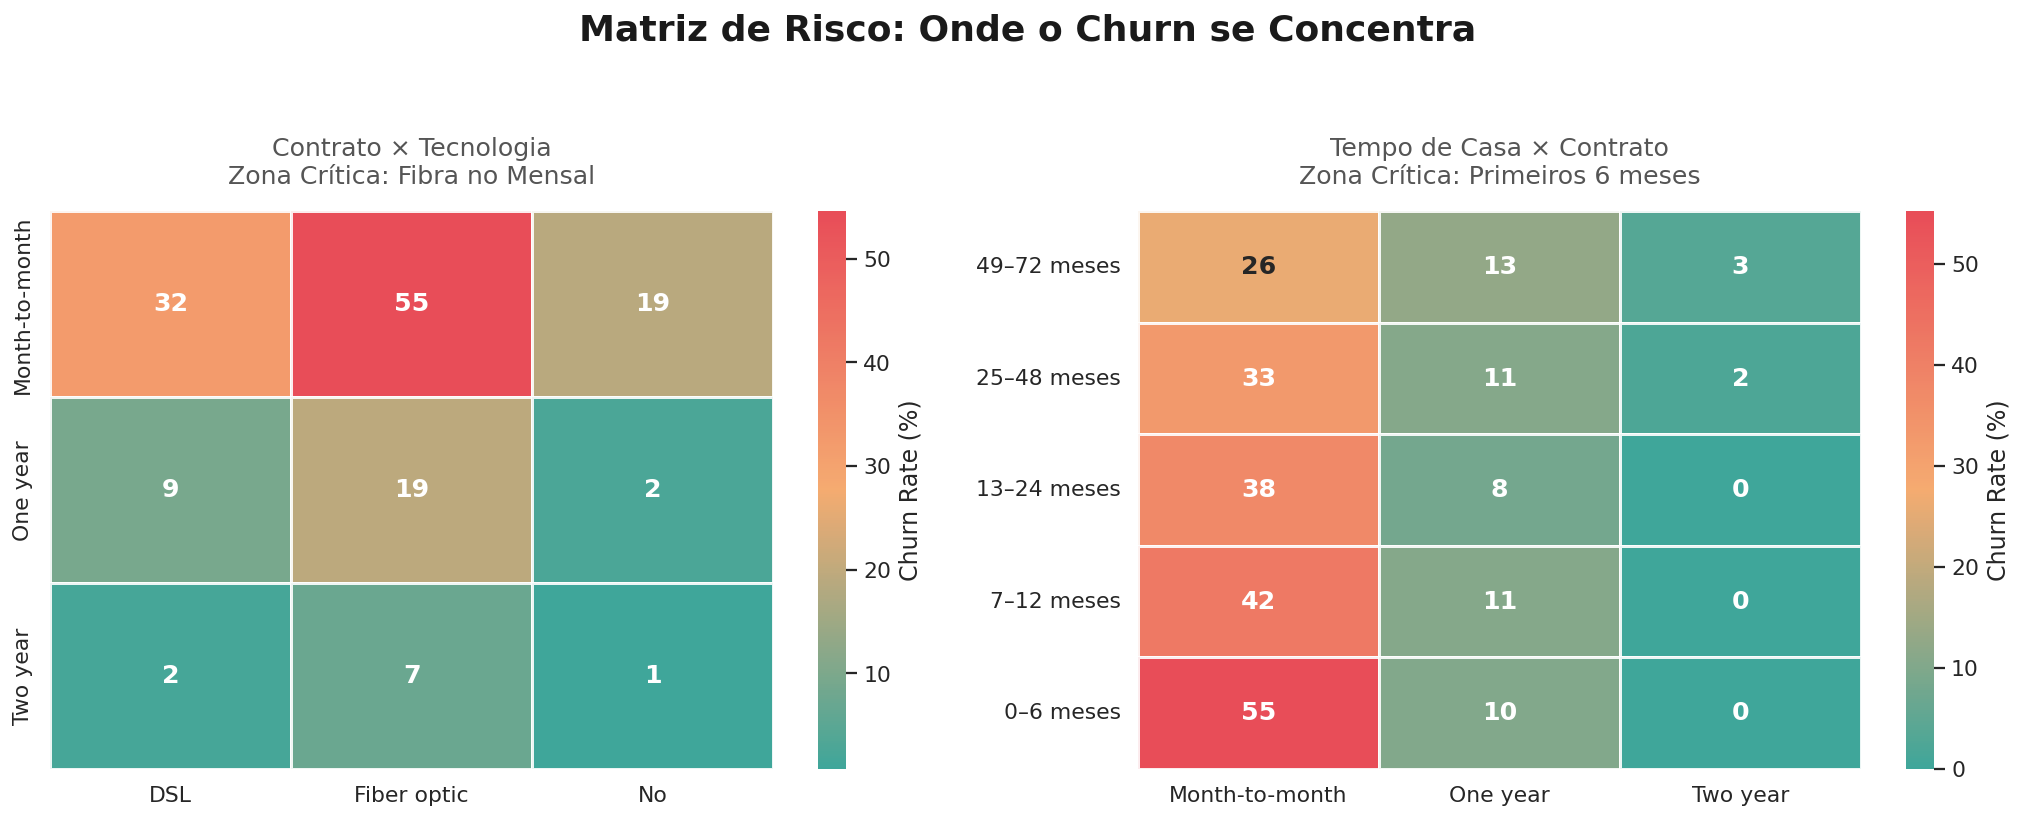

Taxa de Churn (Pior Segmento): 74.15%
Total de Clientes no Segmento: 619
Receita Mensal Perdida (Churners): R$ 37,150.15


In [61]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['text.color'] = '#2b2b2b'

sns.set_theme(style="white", font_scale=1.1)
cmap_risk = LinearSegmentedColormap.from_list("risk", ["#2A9D8F", "#F4A261", "#E63946"])

# Preparação das Tabelas Dinâmicas
pivot1 = df.pivot_table(values='y', index='Contract', columns='InternetService', aggfunc='mean') * 100
pivot1 = pivot1.reindex(['Month-to-month', 'One year', 'Two year'])

pivot2 = df.pivot_table(values='y', index='tenure_faixa', columns='Contract', aggfunc='mean') * 100
# Reordenando Tenure (ajuste os nomes conforme sua coluna tenure_faixa)
pivot2 = pivot2.reindex(index=pivot2.index[::-1])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matriz de Risco: Onde o Churn se Concentra', fontsize=20, fontweight='bold', color='#1a1a1a', y=1.05)

# Contrato x Internet
sns.heatmap(pivot1, annot=True, fmt='.0f', cmap=cmap_risk, ax=axes[0],
            linewidths=1.5, annot_kws={'size':14, 'fontweight':'bold'},
            cbar_kws={'label': 'Churn Rate (%)'}, alpha=0.9)
axes[0].set_title('Contrato × Tecnologia\nZona Crítica: Fibra no Mensal', fontsize=14, color='#555555', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Tenure x Contrato
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap=cmap_risk, ax=axes[1],
            linewidths=1.5, annot_kws={'size':14, 'fontweight':'bold'},
            cbar_kws={'label': 'Churn Rate (%)'}, alpha=0.9)
axes[1].set_title('Tempo de Casa × Contrato\nZona Crítica: Primeiros 6 meses', fontsize=14, color='#555555', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [78]:
# Preparar features
features = ['Contract', 'InternetService', 'tenure',
            'PaymentMethod', 'n_services', 'MonthlyCharges',
            'SeniorCitizen', 'TechSupport', 'OnlineSecurity']

df_tree = df[features + ['y']].copy()

# Encoding das categóricas
le = {}
for col in df_tree.select_dtypes('object').columns:
    le[col] = LabelEncoder()
    df_tree[col] = le[col].fit_transform(df_tree[col])

X = df_tree[features]
y = df_tree['y']

tree = DecisionTreeClassifier(
    max_depth=3,          # 3 níveis = legível numa slide
    min_samples_leaf=100, # mínimo 100 clientes por folha
    class_weight='balanced',
    random_state=42
)
tree.fit(X, y)

# Texto da árvore
print(export_text(tree, feature_names=features))
print()

# Churn rate e volume por folha
df_tree['leaf'] = tree.apply(X)
leaf_stats = df_tree.groupby('leaf')['y'].agg(
    churn_rate='mean', n='count'
).sort_values('churn_rate', ascending=False)
print(leaf_stats.round(3))

|--- Contract <= 0.50
|   |--- OnlineSecurity <= 0.50
|   |   |--- tenure <= 10.50
|   |   |   |--- class: 1
|   |   |--- tenure >  10.50
|   |   |   |--- class: 1
|   |--- OnlineSecurity >  0.50
|   |   |--- MonthlyCharges <= 91.45
|   |   |   |--- class: 0
|   |   |--- MonthlyCharges >  91.45
|   |   |   |--- class: 1
|--- Contract >  0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- Contract <= 1.50
|   |   |   |--- class: 0
|   |   |--- Contract >  1.50
|   |   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- Contract <= 1.50
|   |   |   |--- class: 0
|   |   |--- Contract >  1.50
|   |   |   |--- class: 0


      churn_rate     n
leaf                  
3          0.634  1259
7          0.426   183
4          0.397  1372
13         0.224   398
6          0.221  1061
14         0.079   380
10         0.072  1075
11         0.014  1315


In [79]:
for col in le:
    print(f"{col}: {list(enumerate(le[col].classes_))}")

Contract: [(0, 'Month-to-month'), (1, 'One year'), (2, 'Two year')]
InternetService: [(0, 'DSL'), (1, 'Fiber optic'), (2, 'No')]
PaymentMethod: [(0, 'Bank transfer (automatic)'), (1, 'Credit card (automatic)'), (2, 'Electronic check'), (3, 'Mailed check')]
TechSupport: [(0, 'No'), (1, 'No internet service'), (2, 'Yes')]
OnlineSecurity: [(0, 'No'), (1, 'No internet service'), (2, 'Yes')]


In [81]:
df_tree['leaf'] = tree.apply(X)

leaf_map = {
    3:  'M2M + Sem Segurança + Tenure ≤ 10m',
    4:  'M2M + Sem Segurança + Tenure > 10m',
    7:  'M2M + Com Segurança + Charges > R$91',
    6:  'M2M + Com Segurança + Charges ≤ R$91',
    10: 'Anual + Charges ≤ R$94',
    11: '2 Anos + Charges ≤ R$94',
    13: 'Anual + Charges > R$94',
    14: '2 Anos + Charges > R$94',
}

result = df_tree.copy()
result['leaf_nome'] = result['leaf'].map(leaf_map)
result['MonthlyCharges'] = df['MonthlyCharges']

stats = result.groupby('leaf_nome').agg(
    n=('y','count'),
    churn_rate=('y','mean'),
    arpu=('MonthlyCharges','mean'),
).sort_values('churn_rate', ascending=False)

stats['rec_risco_mensal'] = (stats['n'] * stats['churn_rate'] * stats['arpu']).round(0)
stats['pct_churners'] = (stats['n'] * stats['churn_rate'] / df['y'].sum()).round(3)

print(stats.round(3).to_string())

                                         n  churn_rate     arpu  rec_risco_mensal  pct_churners
leaf_nome                                                                                      
M2M + Sem Segurança + Tenure ≤ 10m    1259       0.634   67.421           53802.0         0.427
M2M + Com Segurança + Charges > R$91   183       0.426  101.292            7901.0         0.042
M2M + Sem Segurança + Tenure > 10m    1372       0.397   79.093           43106.0         0.292
Anual + Charges > R$94                 398       0.224  103.227            9187.0         0.048
M2M + Com Segurança + Charges ≤ R$91  1061       0.221   42.750           10004.0         0.125
2 Anos + Charges > R$94                380       0.079  107.041            3211.0         0.016
Anual + Charges ≤ R$94                1075       0.072   50.914            3920.0         0.041
2 Anos + Charges ≤ R$94               1315       0.014   47.399             853.0         0.010


Foi usada uma Árvore de Decisão (profundidade 3, mínimo 100 clientes
por folha) para segmentar a base. O algoritmo testa cada variável em cada nó e
escolhe o critério que melhor separa churners de retidos.

**Três critérios emergiram em ordem de poder preditivo:**

Contrato → OnlineSecurity → Tenure/MonthlyCharges.

In [82]:
# Validar: Fiber com segurança tem churn parecido com DSL com segurança?
grupos = {
    'Fiber + Sem Segurança': df[(df['InternetService']=='Fiber optic') &
                                 (df['OnlineSecurity']=='No') &
                                 (df['Contract']=='Month-to-month')],
    'DSL + Sem Segurança':   df[(df['InternetService']=='DSL') &
                                 (df['OnlineSecurity']=='No') &
                                 (df['Contract']=='Month-to-month')],
    'Fiber + Com Segurança': df[(df['InternetService']=='Fiber optic') &
                                 (df['OnlineSecurity']=='Yes') &
                                 (df['Contract']=='Month-to-month')],
    'DSL + Com Segurança':   df[(df['InternetService']=='DSL') &
                                 (df['OnlineSecurity']=='Yes') &
                                 (df['Contract']=='Month-to-month')],
}

for nome, seg in grupos.items():
    print(f"{nome:<30} N={len(seg):>4} | Churn={seg['y'].mean():.1%} | ARPU=R${seg['MonthlyCharges'].mean():.0f}")

Fiber + Sem Segurança          N=1774 | Churn=58.1% | ARPU=R$86
DSL + Sem Segurança            N= 857 | Churn=36.4% | ARPU=R$48
Fiber + Com Segurança          N= 354 | Churn=37.0% | ARPU=R$92
DSL + Com Segurança            N= 366 | Churn=22.4% | ARPU=R$56


O modelo escolheu OnlineSecurity como segundo critério porque tem
maior poder preditivo agregado dentro do M2M. Isso não significa
que Fiber é irrelevante — significa que a ausência de OnlineSecurity
é o fator de maior separação quando olhamos a base M2M inteira.

Controlando por OnlineSecurity, Fiber ainda tem efeito independente:
- Sem segurança: Fiber (58%) vs DSL (36%) — gap de 22pp
- Com segurança: Fiber (37%) vs DSL (22%) — gap de 15pp

Os dois fatores são independentes e se acumulam. OnlineSecurity
reduz o churn em ~21pp no Fiber e ~14pp no DSL. Fiber adiciona
~15-22pp de risco acima do DSL independentemente da segurança.

In [83]:
alvo = df[(df['InternetService']=='Fiber optic') &
          (df['Contract']=='Month-to-month') &
          (df['OnlineSecurity']=='No')]

print(f"N: {len(alvo):,}")
print(f"Churn: {alvo['y'].mean():.1%}")
print(f"ARPU: R${alvo['MonthlyCharges'].mean():.2f}")
print(f"Receita mensal em risco: R${alvo[alvo['y']==1]['MonthlyCharges'].sum():,.0f}")
print(f"% dos churners totais: {alvo['y'].sum()/df['y'].sum():.1%}")

N: 1,774
Churn: 58.1%
ARPU: R$85.96
Receita mensal em risco: R$88,352
% dos churners totais: 55.2%


---
## Pergunta 5: O que podemos fazer que vai realmente mover o ponteiro?

Indetificamos onde o churn se concentra e quais variáveis
têm relação direta com ele. As intervenções abaixo derivam dos padrões encontrados aqui.

---

### O Segmento Central

**Fiber + M2M + Sem OnlineSecurity**

1.774 clientes | 58,1% de churn | ARPU R\$ 86 | R\$ 88.352 ao mês em risco

55,2% de todo o churn da empresa está aqui.

Três fatores coexistem nesse segmento e cada um tem efeito
independente, medido nos dados:

**Contrato M2M:** maior poder preditivo de toda a base.
Clientes M2M têm 42,7% de churn. Clientes não-M2M têm 6,8%.
Diferença de 36pp — o maior gap observado em qualquer variável.

**Ausência de OnlineSecurity:** controlando pelo tipo de internet,
clientes Fiber sem segurança têm 58,1% de churn. Fiber com
segurança: 37,0%. Diferença de 21pp dentro do mesmo produto
e mesmo tipo de contrato.

**Fiber Optic:** controlando por OnlineSecurity, Fiber tem churn
superior ao DSL em todos os cenários. Sem segurança: Fiber 58%
vs DSL 36% — gap de 22pp. Com segurança: Fiber 37% vs DSL 22%
— gap de 15pp. O efeito de Fiber é independente e persiste mesmo
com serviços adicionais contratados.

Os três fatores não se explicam mutuamente. São aditivos.

---

### Alavanca 1 — OnlineSecurity no onboarding Fiber M2M

O dado: Fiber M2M sem segurança tem 58,1% de churn.
Fiber M2M com segurança tem 37,0%. Diferença de 21pp.
Essa diferença foi medida dentro do mesmo segmento de produto
e contrato — não há outra variável principal que a explique
nos dados disponíveis.

**O que fazer:** Teste A/B de Oferta: Oferecer 3 meses grátis de OnlineSecurity no onboarding para clientes Fiber + M2M. Objetivo: Validar a hipótese de que a percepção de segurança/valor agregado reduz o churn neste grupo sensível.

**Impacto potencial nos dados:** reduzir 10pp de churn nesse
segmento retém ~177 clientes/mês. A R\$86 de ARPU:
R\$15.222/mês em receita recorrente preservada.

---

### Alavanca 2 — Oferta de migração para anual entre meses 8-10

O dado: a árvore de decisão identificou tenure ≤ 10,5 meses
como o threshold de maior separação dentro do M2M. Clientes
que chegam ao mês 11 têm 39,7% de churn. Antes disso: 63,4%.

O mês 8-10 é o ponto onde o cliente já viveu o produto tempo
suficiente para tomar uma decisão informada, e ainda não está
no pico de risco de saída. É a janela mais favorável para
oferecer migração para contrato anual.

**O que fazer:** oferta ativa de migração para contrato anual
para clientes M2M entre o 8º e o 10º mês. O incentivo
específico — desconto, serviço adicional, upgrade — não está
nos dados e precisa ser definido e testado pela empresa.

**Referência dos dados:** clientes em contrato anual com
ARPU equivalente têm 22,4% de churn. O mesmo cliente em M2M
tem 40-58% dependendo do segmento.

---

### Alavanca 3 — Electronic check como gatilho de retenção

O dado: clientes M2M em electronic check têm 45,3% de churn
vs 16% em pagamento automático. Diferença de 29pp.

**O que os dados não permitem concluir:** se o pagamento manual
causa o churn ou se quem já decidiu sair migra para manual
para facilitar o cancelamento. Os dados mostram associação,
não causalidade.

**O que fazer independentemente da direção causal:** tratar
electronic check como sinal de alerta no CRM. Clientes M2M
que estão em electronic check — ou que migram de automático
para manual — entram em fluxo de contato proativo.

A intervenção é a mesma nos dois cenários causais: agir antes
do cancelamento formal.

---

### O Que Não Está nos Dados

Fiber tem churn 15-22pp acima do DSL mesmo com OnlineSecurity
contratada. Os dados mostram o padrão mas não explicam a causa.
As hipóteses — qualidade técnica, expectativa de venda,
custo-benefício percebido — requerem dados de suporte, NPS
ou pesquisa qualitativa. Essa é a principal lacuna desta análise
e o ponto de partida para a fase seguinte.

---

### Priorização

| # | Segmento alvo | Churn atual | Receita em risco | Ação |
|---|---|---|---|---|
| 1 | Fiber + M2M + Sem OnlineSecurity | 58,1% | R\$88.352/mês | OnlineSecurity no onboarding |
| 2 | M2M com tenure 8-10 meses | ~50% | — | Oferta de migração para anual |
| 3 | M2M + Electronic check | 45,3% | R\$77.316/mês | Gatilho de retenção no CRM |

A Alavanca 1 tem o maior segmento, o maior churn, a maior receita
em risco e a hipótese mais diretamente testável com A/B test.
É o ponto de partida.